# 7. Final Model Comparison

Comparison of the six final DLinear models on the same 28-day test horizon

## 1. Imports and paths

In [34]:
from pathlib import Path
import json
import sys

from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "final":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
elif PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from settings.final_config import FINAL_SEEDS, RESULT_ROOT

GRID_DIR = RESULT_ROOT / "grid_results"
PREDICTION_DIR = RESULT_ROOT / "predictions"

MODEL_ORDER = [
    "Basic DLinear",
    "Past-Covariate DLinear",
    "Past-and-Future-Covariate DLinear",
    "Zero-Aware DLinear",
    "Metadata DLinear",
    "Full DLinear",
]

MODEL_LABELS = {
    "Basic DLinear": "Basic",
    "Past-Covariate DLinear": "Past covariates",
    "Past-and-Future-Covariate DLinear": "Past + future",
    "Zero-Aware DLinear": "Zero-aware",
    "Metadata DLinear": "Metadata",
    "Full DLinear": "Full",
}

SUBSET_ORDER = [
    "all_combined",
    "normal",
    "intermittent",
    "cold_start_item",
    "cold_start_store",
]

RESULT_ROOT

WindowsPath('C:/Users/Francisco/Documents/Documentos-secundario/Visual-Studio-Code-Repository/CT5108_Capstone/Unified_forecasting/notebooks/experiments')

## 2. Load final model results

Each model has three final seeds and the same five evaluation subsets.

In [2]:
model_files = {
    "Basic DLinear": "basic_dlinear_final_metrics.csv",
    "Past-Covariate DLinear": "past_covariates_final_metrics.csv",
    "Past-and-Future-Covariate DLinear": "future_covariates_final_metrics.csv",
    "Zero-Aware DLinear": "zero_aware_final_metrics.csv",
    "Metadata DLinear": "metadata_final_metrics.csv",
    "Full DLinear": "full_model_final_metrics.csv",
}

metric_frames = []

for model_name, file_name in model_files.items():
    model_metrics = pd.read_csv(GRID_DIR / file_name)
    metric_frames.append(model_metrics)

final_metrics = pd.concat(metric_frames, ignore_index=True)
baseline_metrics = pd.read_csv(GRID_DIR / "final_baselines.csv")

result_coverage = (
    final_metrics
    .groupby(["model_name", "subset"])["seed"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(index=MODEL_ORDER, columns=SUBSET_ORDER)
)

print("Expected seeds per result:", len(FINAL_SEEDS))
result_coverage

Expected seeds per result: 5


subset,all_combined,normal,intermittent,cold_start_item,cold_start_store
model_name,,,,,
Basic DLinear,5,5,5,5,5
Past-Covariate DLinear,5,5,5,5,5
Past-and-Future-Covariate DLinear,5,5,5,5,5
Zero-Aware DLinear,5,5,5,5,5
Metadata DLinear,5,5,5,5,5
Full DLinear,5,5,5,5,5


## 3. Mean performance across seeds

Standard deviations represent variation between the three final training seeds.

In [3]:
final_summary = (
    final_metrics
    .groupby(["model_name", "subset"])
    .agg(
        seeds=("seed", "nunique"),
        mae=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        wape=("wape", "mean"),
        wape_std=("wape", "std"),
        zero_precision=("zero_precision", "mean"),
        zero_recall=("zero_recall", "mean"),
        zero_f1=("zero_f1", "mean"),
        zero_f1_std=("zero_f1", "std"),
        total_actual_demand=("total_actual_demand", "mean"),
        total_predicted_demand=("total_predicted_demand", "mean"),
    )
    .reset_index()
)

final_summary.to_csv(
    GRID_DIR / "final_learned_model_summary.csv",
    index=False,
)

final_summary.head()

,model_name,subset,seeds,mae,mae_std,rmse,rmse_std,wape,wape_std,zero_precision,zero_recall,zero_f1,zero_f1_std,total_actual_demand,total_predicted_demand
0,Basic DLinear,all_combined,5,1.006883,0.006593,2.330386,0.049142,0.726240,0.004755,0.762931,0.750470,0.756596,0.003102,1183626.0,885329.825000
1,Basic DLinear,cold_start_item,5,1.139514,0.009155,2.853855,0.113263,0.724002,0.005816,0.752748,0.723581,0.737818,0.003423,134412.0,102350.225000
2,Basic DLinear,cold_start_store,5,1.056528,0.007288,2.293208,0.045087,0.715944,0.004938,0.759584,0.706245,0.731868,0.004407,113382.0,84452.004687
3,Basic DLinear,intermittent,5,0.605819,0.001303,1.193365,0.013570,0.966014,0.002077,0.776442,0.849811,0.811441,0.002085,300201.0,215239.303125
4,Basic DLinear,normal,5,1.837913,0.021439,3.662608,0.074052,0.615307,0.007177,0.635385,0.313849,0.419826,0.013847,635631.0,483288.287500


## 4. All-combined results

The table shows the overall result across all 30,490 series. Positive improvement percentages mean that the model improved over Basic DLinear.

In [4]:
all_combined_results = (
    final_summary[final_summary["subset"] == "all_combined"]
    .set_index("model_name")
    .reindex(MODEL_ORDER)
    .reset_index()
)

basic_all_combined = all_combined_results[
    all_combined_results["model_name"] == "Basic DLinear"
].iloc[0]

for metric in ["mae", "rmse", "wape"]:
    reference_value = basic_all_combined[metric]
    all_combined_results[f"{metric}_improvement_vs_basic_pct"] = (
        100
        * (reference_value - all_combined_results[metric])
        / reference_value
    )

all_combined_results["zero_f1_change_vs_basic_pp"] = 100 * (
    all_combined_results["zero_f1"]
    - basic_all_combined["zero_f1"]
)
all_combined_results["predicted_to_actual_pct"] = 100 * (
    all_combined_results["total_predicted_demand"]
    / all_combined_results["total_actual_demand"]
)

all_combined_columns = [
    "model_name",
    "mae",
    "rmse",
    "wape",
    "zero_precision",
    "zero_recall",
    "zero_f1",
    "wape_improvement_vs_basic_pct",
    "rmse_improvement_vs_basic_pct",
    "zero_f1_change_vs_basic_pp",
    "predicted_to_actual_pct",
]

display(
    all_combined_results[all_combined_columns]
    .round(4)
)

,model_name,mae,rmse,wape,zero_precision,zero_recall,zero_f1,wape_improvement_vs_basic_pct,rmse_improvement_vs_basic_pct,zero_f1_change_vs_basic_pp,predicted_to_actual_pct
0,Basic DLinear,1.0069,2.3304,0.7262,0.7629,0.7505,0.7566,0.0000,0.0000,0.0000,74.7981
1,Past-Covariate DLinear,1.0188,2.3568,0.7348,0.7614,0.7378,0.7492,-1.1791,-1.1348,-0.7396,74.0377
2,Past-and-Future-Covariate DLinear,1.0174,2.3578,0.7338,0.7585,0.7426,0.7502,-1.0434,-1.1762,-0.6350,72.9078
3,Zero-Aware DLinear,1.0131,2.3113,0.7307,0.6942,0.8972,0.7828,-0.6150,0.8187,2.6165,82.4857
4,Metadata DLinear,1.0176,2.3588,0.7340,0.7621,0.7367,0.7490,-1.0670,-1.2209,-0.7584,73.9315
5,Full DLinear,1.0080,2.2875,0.7270,0.6973,0.8925,0.7829,-0.1091,1.8421,2.6318,83.2905


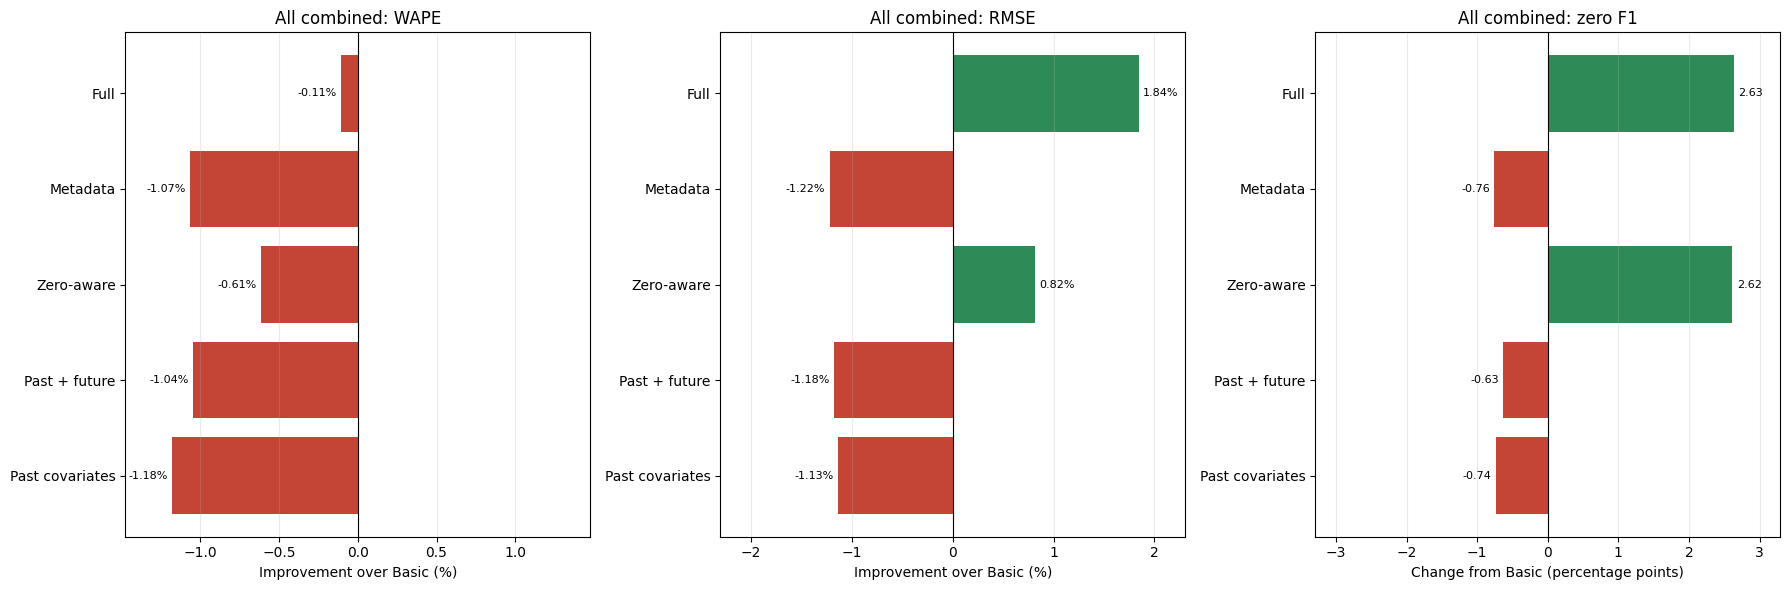

In [30]:
def plot_change_bars(axis, values, title, label, value_format):
    # Find the positions of every model except Basic.
    positions_to_keep = [
        position
        for position, name in enumerate(MODEL_ORDER)
        if MODEL_LABELS[name] != "Basic"
    ]

    comparison_models = [
        MODEL_ORDER[position]
        for position in positions_to_keep
    ]

    # Select values by position because the Series has a numeric index.
    plot_values = (
        values.iloc[positions_to_keep]
        .to_numpy(dtype=float)
    )

    colors = [
        "#2E8B57" if value > 0
        else "#C44536" if value < 0
        else "#7F8C8D"
        for value in plot_values
    ]

    bars = axis.barh(
        [MODEL_LABELS[name] for name in comparison_models],
        plot_values,
        color=colors,
    )

    axis.axvline(0, color="black", linewidth=0.8)

    axis.bar_label(
        bars,
        fmt=value_format,
        padding=3,
        fontsize=8,
    )

    axis.set_title(title)
    axis.set_xlabel(label)
    axis.grid(axis="x", alpha=0.25)

    # Use symmetric limits so zero is always visible.
    maximum = np.max(np.abs(plot_values))
    margin = max(maximum * 0.25, 0.1)
    axis.set_xlim(-maximum - margin, maximum + margin)


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_change_bars(
    axes[0],
    all_combined_results["wape_improvement_vs_basic_pct"],
    "All combined: WAPE",
    "Improvement over Basic (%)",
    "%.2f%%",
)

plot_change_bars(
    axes[1],
    all_combined_results["rmse_improvement_vs_basic_pct"],
    "All combined: RMSE",
    "Improvement over Basic (%)",
    "%.2f%%",
)

plot_change_bars(
    axes[2],
    all_combined_results["zero_f1_change_vs_basic_pp"],
    "All combined: zero F1",
    "Change from Basic (percentage points)",
    "%.2f",
)

plt.tight_layout()
plt.show()

## 5. Results by subset

These tables show the exact values and changes from Basic DLinear for every subset.

In [23]:
final_summary[final_summary["subset"] == "normal"]

,model_name,subset,seeds,mae,mae_std,rmse,rmse_std,wape,wape_std,zero_precision,zero_recall,zero_f1,zero_f1_std,total_actual_demand,total_predicted_demand
4,Basic DLinear,normal,5,1.837913,0.021439,3.662608,0.074052,0.615307,0.007177,0.635385,0.313849,0.419826,0.013847,635631.0,483288.28750
9,Full DLinear,normal,5,1.824911,0.004822,3.608065,0.032470,0.610954,0.001614,0.528080,0.614413,0.567939,0.002107,635631.0,539313.31250
14,Metadata DLinear,normal,5,1.859727,0.026148,3.737793,0.096346,0.622610,0.008754,0.625462,0.324766,0.427052,0.016766,635631.0,469730.16875
19,Past-Covariate DLinear,normal,5,1.859429,0.026248,3.734902,0.096742,0.622510,0.008787,0.623275,0.327554,0.428897,0.017337,635631.0,469926.16875
24,Past-and-Future-Covariate DLinear,normal,5,1.860094,0.023716,3.737711,0.085448,0.622732,0.007940,0.617386,0.339504,0.437416,0.019100,635631.0,463532.15000
29,Zero-Aware DLinear,normal,5,1.836566,0.006169,3.650400,0.044009,0.614856,0.002065,0.522912,0.626354,0.569935,0.001872,635631.0,534109.15000


In [6]:
basic_reference = (
    final_summary[final_summary["model_name"] == "Basic DLinear"]
    [["subset", "mae", "rmse", "wape", "zero_f1"]]
    .rename(columns={
        "mae": "basic_mae",
        "rmse": "basic_rmse",
        "wape": "basic_wape",
        "zero_f1": "basic_zero_f1",
    })
)

subset_comparison = final_summary.merge(
    basic_reference,
    on="subset",
    how="left",
)

for metric in ["mae", "rmse", "wape"]:
    subset_comparison[f"{metric}_improvement_vs_basic_pct"] = (
        100
        * (
            subset_comparison[f"basic_{metric}"]
            - subset_comparison[metric]
        )
        / subset_comparison[f"basic_{metric}"]
    )

subset_comparison["zero_f1_change_vs_basic_pp"] = 100 * (
    subset_comparison["zero_f1"]
    - subset_comparison["basic_zero_f1"]
)

subset_comparison.to_csv(
    GRID_DIR / "final_comparison_summary.csv",
    index=False,
)

wape_values = (
    subset_comparison
    .pivot(index="subset", columns="model_name", values="wape")
    .reindex(index=SUBSET_ORDER, columns=MODEL_ORDER)
)
wape_improvement = (
    subset_comparison
    .pivot(
        index="subset",
        columns="model_name",
        values="wape_improvement_vs_basic_pct",
    )
    .reindex(index=SUBSET_ORDER, columns=MODEL_ORDER)
)
rmse_improvement = (
    subset_comparison
    .pivot(
        index="subset",
        columns="model_name",
        values="rmse_improvement_vs_basic_pct",
    )
    .reindex(index=SUBSET_ORDER, columns=MODEL_ORDER)
)
zero_f1_change = (
    subset_comparison
    .pivot(
        index="subset",
        columns="model_name",
        values="zero_f1_change_vs_basic_pp",
    )
    .reindex(index=SUBSET_ORDER, columns=MODEL_ORDER)
)

print("Mean test WAPE")
display(wape_values.round(4))

print("Relative WAPE improvement over Basic DLinear (%)")
display(wape_improvement.round(2))

Mean test WAPE


model_name,Basic DLinear,Past-Covariate DLinear,Past-and-Future-Covariate DLinear,Zero-Aware DLinear,Metadata DLinear,Full DLinear
subset,,,,,,
all_combined,0.7262,0.7348,0.7338,0.7307,0.7340,0.7270
normal,0.6153,0.6225,0.6227,0.6149,0.6226,0.6110
intermittent,0.9660,0.9782,0.9751,0.9814,0.9753,0.9777
cold_start_item,0.7240,0.7266,0.7248,0.7257,0.7263,0.7226
cold_start_store,0.7159,0.7297,0.7283,0.7224,0.7288,0.7192


Relative WAPE improvement over Basic DLinear (%)


model_name,Basic DLinear,Past-Covariate DLinear,Past-and-Future-Covariate DLinear,Zero-Aware DLinear,Metadata DLinear,Full DLinear
subset,,,,,,
all_combined,0.0,-1.18,-1.04,-0.61,-1.07,-0.11
normal,0.0,-1.17,-1.21,0.07,-1.19,0.71
intermittent,0.0,-1.26,-0.94,-1.59,-0.96,-1.21
cold_start_item,0.0,-0.35,-0.11,-0.23,-0.31,0.19
cold_start_store,0.0,-1.92,-1.72,-0.91,-1.79,-0.46


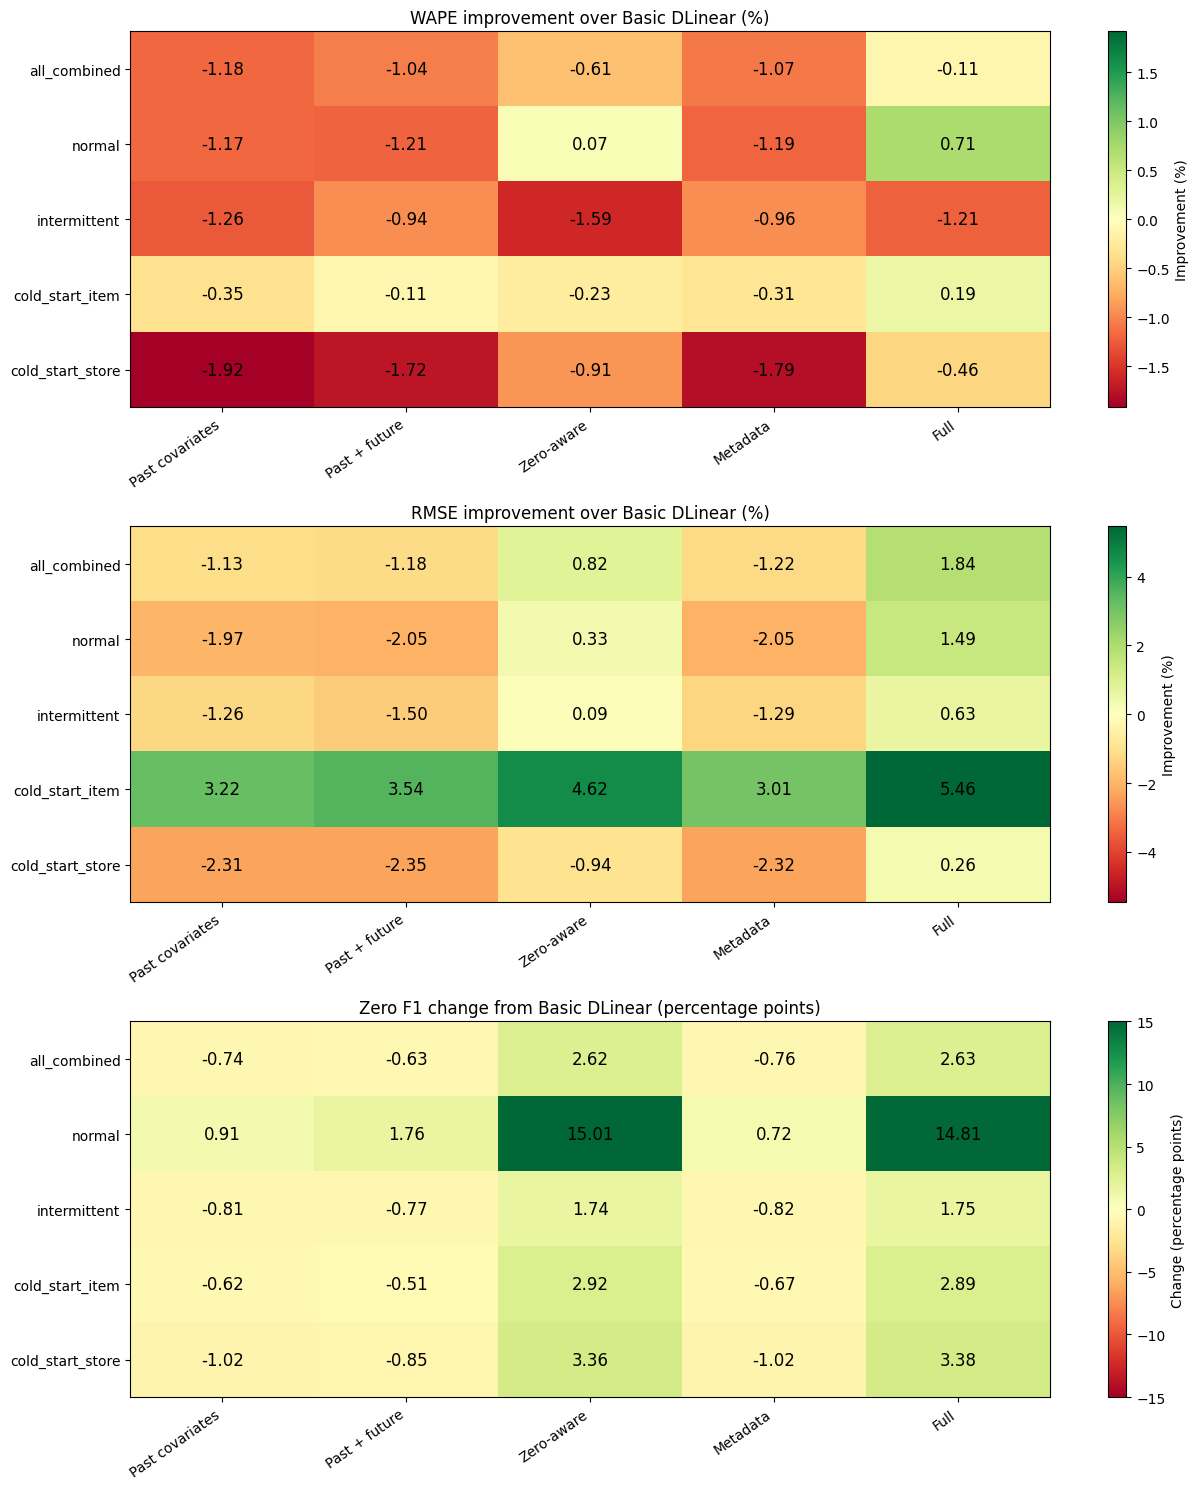

In [27]:
def annotated_heatmap(axis, values, title, number_format):
    # Remove Basic because its improvement is always zero.
    columns_to_keep = [
        column
        for column in values.columns
        if MODEL_LABELS[column] != "Basic"
    ]
    values = values[columns_to_keep]

    maximum = np.nanmax(np.abs(values.to_numpy()))
    norm = TwoSlopeNorm(vmin=-maximum, vcenter=0, vmax=maximum)

    image = axis.imshow(
        values,
        cmap="RdYlGn",
        norm=norm,
        aspect="auto",
    )

    axis.set_xticks(range(len(values.columns)))
    axis.set_xticklabels(
        [MODEL_LABELS[name] for name in values.columns],
        rotation=35,
        ha="right",
    )

    axis.set_yticks(range(len(values.index)))
    axis.set_yticklabels(values.index)
    axis.set_title(title)

    # Write the metric value inside each cell.
    for row in range(len(values.index)):
        for column in range(len(values.columns)):
            value = values.iloc[row, column]

            axis.text(
                column,
                row,
                format(value, number_format),
                ha="center",
                va="center",
                fontsize=12,
            )

    return image


fig, axes = plt.subplots(3, 1, figsize=(13, 15))

image = annotated_heatmap(
    axes[0],
    wape_improvement,
    "WAPE improvement over Basic DLinear (%)",
    ".2f",
)
fig.colorbar(image, ax=axes[0], label="Improvement (%)")

image = annotated_heatmap(
    axes[1],
    rmse_improvement,
    "RMSE improvement over Basic DLinear (%)",
    ".2f",
)
fig.colorbar(image, ax=axes[1], label="Improvement (%)")

image = annotated_heatmap(
    axes[2],
    zero_f1_change,
    "Zero F1 change from Basic DLinear (percentage points)",
    ".2f",
)
fig.colorbar(
    image,
    ax=axes[2],
    label="Change (percentage points)",
)

plt.tight_layout()
plt.show()

## 6. Best model by subset

The best model depends on whether the priority is absolute error, large errors, or zero-demand classification.

In [8]:
finding_rows = []

for subset_name in SUBSET_ORDER:
    subset_data = final_summary[
        final_summary["subset"] == subset_name
    ]
    basic_data = subset_data[
        subset_data["model_name"] == "Basic DLinear"
    ].iloc[0]

    best_mae = subset_data.loc[subset_data["mae"].idxmin()]
    best_rmse = subset_data.loc[subset_data["rmse"].idxmin()]
    best_wape = subset_data.loc[subset_data["wape"].idxmin()]
    best_zero_f1 = subset_data.loc[subset_data["zero_f1"].idxmax()]

    finding_rows.append({
        "subset": subset_name,
        "best_mae_model": best_mae["model_name"],
        "best_mae": best_mae["mae"],
        "best_rmse_model": best_rmse["model_name"],
        "best_rmse": best_rmse["rmse"],
        "rmse_improvement_vs_basic_pct": 100 * (
            basic_data["rmse"] - best_rmse["rmse"]
        ) / basic_data["rmse"],
        "best_wape_model": best_wape["model_name"],
        "best_wape": best_wape["wape"],
        "wape_improvement_vs_basic_pct": 100 * (
            basic_data["wape"] - best_wape["wape"]
        ) / basic_data["wape"],
        "best_zero_f1_model": best_zero_f1["model_name"],
        "best_zero_f1": best_zero_f1["zero_f1"],
        "zero_f1_change_vs_basic_pp": 100 * (
            best_zero_f1["zero_f1"] - basic_data["zero_f1"]
        ),
    })

subset_findings = pd.DataFrame(finding_rows)
subset_findings.to_csv(
    GRID_DIR / "final_subset_findings.csv",
    index=False,
)

display(subset_findings.round(4))

,subset,best_mae_model,best_mae,best_rmse_model,best_rmse,rmse_improvement_vs_basic_pct,best_wape_model,best_wape,wape_improvement_vs_basic_pct,best_zero_f1_model,best_zero_f1,zero_f1_change_vs_basic_pp
0,all_combined,Basic DLinear,1.0069,Full DLinear,2.2875,1.8421,Basic DLinear,0.7262,0.0000,Full DLinear,0.7829,2.6318
1,normal,Full DLinear,1.8249,Full DLinear,3.6081,1.4892,Full DLinear,0.6110,0.7074,Zero-Aware DLinear,0.5699,15.0108
2,intermittent,Basic DLinear,0.6058,Full DLinear,1.1859,0.6285,Basic DLinear,0.9660,0.0000,Full DLinear,0.8289,1.7468
3,cold_start_item,Full DLinear,1.1373,Full DLinear,2.6980,5.4624,Full DLinear,0.7226,0.1940,Zero-Aware DLinear,0.7670,2.9155
4,cold_start_store,Basic DLinear,1.0565,Full DLinear,2.2872,0.2627,Basic DLinear,0.7159,0.0000,Full DLinear,0.7656,3.3756


## 7. Seed consistency

A mean improvement is more convincing when it occurs across multiple final seeds.

In [9]:
basic_by_seed = (
    final_metrics[final_metrics["model_name"] == "Basic DLinear"]
    [["subset", "seed", "mae", "rmse", "wape", "zero_f1"]]
    .rename(columns={
        "mae": "basic_mae",
        "rmse": "basic_rmse",
        "wape": "basic_wape",
        "zero_f1": "basic_zero_f1",
    })
)

paired_seed_results = final_metrics.merge(
    basic_by_seed,
    on=["subset", "seed"],
    how="left",
)
paired_seed_results["wape_improvement_vs_basic_pct"] = 100 * (
    paired_seed_results["basic_wape"]
    - paired_seed_results["wape"]
) / paired_seed_results["basic_wape"]
paired_seed_results["rmse_beats_basic"] = (
    paired_seed_results["rmse"] < paired_seed_results["basic_rmse"]
)
paired_seed_results["wape_beats_basic"] = (
    paired_seed_results["wape"] < paired_seed_results["basic_wape"]
)
paired_seed_results["zero_f1_beats_basic"] = (
    paired_seed_results["zero_f1"]
    > paired_seed_results["basic_zero_f1"]
)

seed_robustness = (
    paired_seed_results[
        paired_seed_results["model_name"] != "Basic DLinear"
    ]
    .groupby(["subset", "model_name"])
    .agg(
        mean_wape_improvement_pct=(
            "wape_improvement_vs_basic_pct",
            "mean",
        ),
        seeds_beating_basic_wape=("wape_beats_basic", "sum"),
        seeds_beating_basic_rmse=("rmse_beats_basic", "sum"),
        seeds_beating_basic_zero_f1=("zero_f1_beats_basic", "sum"),
    )
    .reset_index()
)

seed_robustness.to_csv(
    GRID_DIR / "final_seed_robustness.csv",
    index=False,
)

print("Number of three seeds that beat Basic DLinear on WAPE")
display(
    seed_robustness
    .pivot(
        index="subset",
        columns="model_name",
        values="seeds_beating_basic_wape",
    )
    .reindex(index=SUBSET_ORDER)
)

Number of three seeds that beat Basic DLinear on WAPE


model_name,Full DLinear,Metadata DLinear,Past-Covariate DLinear,Past-and-Future-Covariate DLinear,Zero-Aware DLinear
subset,,,,,
all_combined,2,2,2,2,1
normal,3,2,2,2,3
intermittent,0,1,1,1,0
cold_start_item,2,2,2,2,2
cold_start_store,2,1,1,1,1


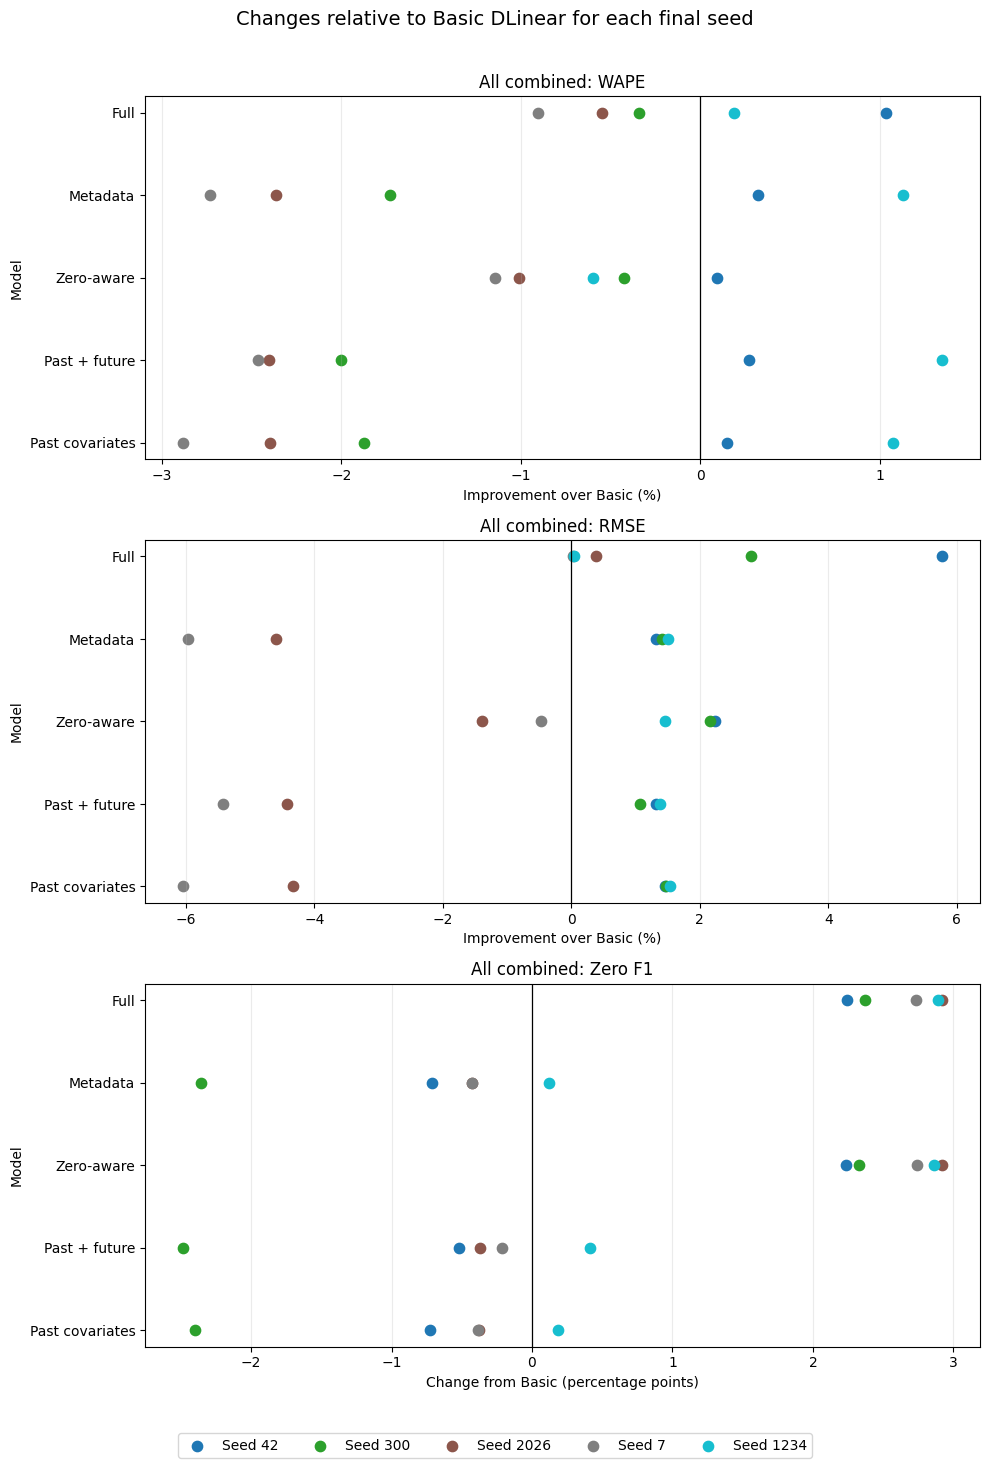

In [ ]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 15),
)

for axis, metric in zip(axes, metric_settings):
    for seed_position, seed in enumerate(FINAL_SEEDS):
        seed_data = (
            all_combined_seed_results[
                all_combined_seed_results["seed"] == seed
            ]
            .set_index("model_name")
            .reindex(comparison_models)
        )

        axis.scatter(
            seed_data[metric["column"]],
            range(len(comparison_models)),
            label=f"Seed {seed}",
            color=seed_colors[seed_position],
            s=55,
        )

    axis.axvline(0, color="black", linewidth=0.9)

    axis.set_yticks(range(len(comparison_models)))
    axis.set_yticklabels(
        [MODEL_LABELS[name] for name in comparison_models]
    )

    axis.set_title(f"All combined: {metric['title']}")
    axis.set_xlabel(metric["xlabel"])
    axis.set_ylabel("Model")
    axis.grid(axis="x", alpha=0.25)


# Create one shared legend below the plots
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(FINAL_SEEDS),
    bbox_to_anchor=(0.5, 0.01),
)

fig.suptitle(
    "Changes relative to Basic DLinear for each final seed",
    fontsize=14,
)

plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

## 8. Total-demand calibration

A value below 100% means that the model underpredicts total demand.

In [11]:
demand_calibration = final_summary.copy()
demand_calibration["predicted_to_actual_pct"] = 100 * (
    demand_calibration["total_predicted_demand"]
    / demand_calibration["total_actual_demand"]
)

demand_calibration_table = (
    demand_calibration
    .pivot(
        index="subset",
        columns="model_name",
        values="predicted_to_actual_pct",
    )
    .reindex(index=SUBSET_ORDER, columns=MODEL_ORDER)
)

display(demand_calibration_table.round(2))

model_name,Basic DLinear,Past-Covariate DLinear,Past-and-Future-Covariate DLinear,Zero-Aware DLinear,Metadata DLinear,Full DLinear
subset,,,,,,
all_combined,74.80,74.04,72.91,82.49,73.93,83.29
normal,76.03,73.93,72.92,84.03,73.90,84.85
intermittent,71.70,72.79,71.44,78.25,72.53,78.74
cold_start_item,76.15,77.46,76.28,85.73,77.25,86.36
cold_start_store,74.48,73.87,72.72,81.21,73.89,82.98


## 9. Error on zero and nonzero days

WAPE can be separated into error contributed by actual zero-demand days and actual nonzero-demand days. This explains why a model can improve RMSE and zero F1 without improving total WAPE.

In [19]:
error_component_rows = []

for prediction_path in sorted(
    PREDICTION_DIR.glob("*_test_predictions.parquet")
):
    prediction_data = pd.read_parquet(
        prediction_path,
        columns=[
            "model_name",
            "seed",
            "subset",
            "actual_sales",
            "predicted_sales",
        ],
    )
    prediction_data["absolute_error"] = np.abs(
        prediction_data["predicted_sales"]
        - prediction_data["actual_sales"]
    )

    for group_values, group in prediction_data.groupby(
        ["model_name", "seed", "subset"],
        sort=False,
    ):
        model_name, seed, subset_name = group_values
        actual_zero = group["actual_sales"] == 0
        actual_demand = group["actual_sales"].sum()

        error_component_rows.append({
            "model_name": model_name,
            "seed": seed,
            "subset": subset_name,
            "zero_day_wape_component": (
                group.loc[actual_zero, "absolute_error"].sum()
                / actual_demand
            ),
            "nonzero_day_wape_component": (
                group.loc[~actual_zero, "absolute_error"].sum()
                / actual_demand
            ),
        })

error_components = (
    pd.DataFrame(error_component_rows)
    .groupby(["model_name", "subset"])
    [["zero_day_wape_component", "nonzero_day_wape_component"]]
    .mean()
    .reset_index()
)
error_components["total_wape"] = (
    error_components["zero_day_wape_component"]
    + error_components["nonzero_day_wape_component"]
)

error_components.to_csv(
    GRID_DIR / "final_wape_error_decomposition.csv",
    index=False,
)

focus_models = [
    "Basic DLinear",
    "Zero-Aware DLinear",
    "Full DLinear",
]
focus_components = error_components[
    error_components["model_name"].isin(focus_models)
]

display(
    focus_components[
        focus_components["subset"].isin(["normal", "intermittent"])
    ]
    .sort_values(["subset", "model_name"])
    .round(4)
)

,model_name,subset,zero_day_wape_component,nonzero_day_wape_component,total_wape
2,Basic DLinear,intermittent,0.3134,0.6526,0.9660
6,Full DLinear,intermittent,0.3372,0.6406,0.9777
22,Zero-Aware DLinear,intermittent,0.3372,0.6442,0.9814
3,Basic DLinear,normal,0.1061,0.5092,0.6153
7,Full DLinear,normal,0.1208,0.4902,0.6110
23,Zero-Aware DLinear,normal,0.1196,0.4953,0.6149


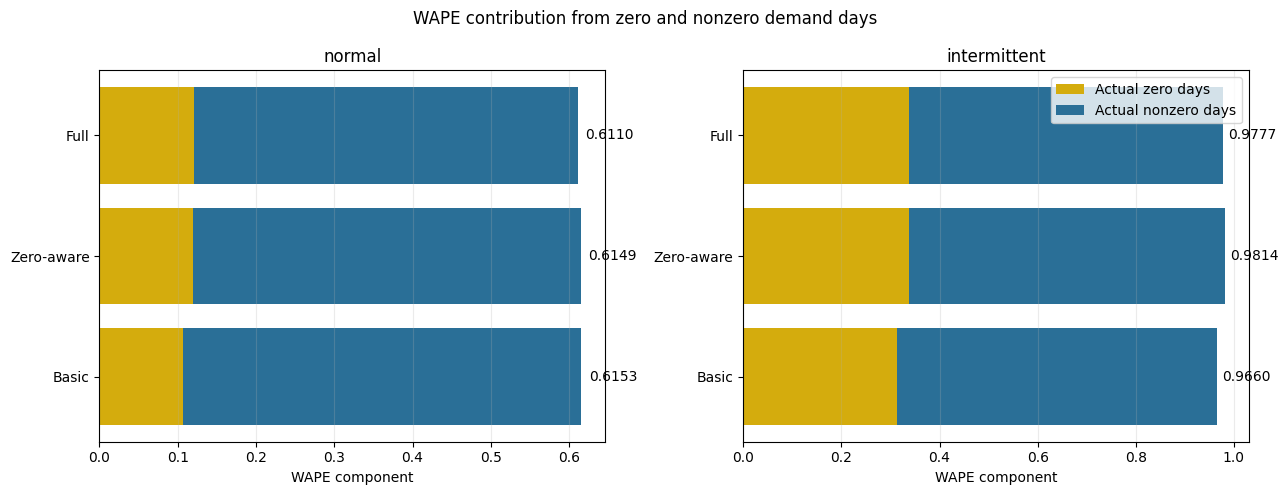

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for axis, subset_name in zip(axes, ["normal", "intermittent"]):
    plot_data = (
        focus_components[focus_components["subset"] == subset_name]
        .set_index("model_name")
        .reindex(focus_models)
    )
    labels = [MODEL_LABELS[name] for name in focus_models]

    zero_bars = axis.barh(
        labels,
        plot_data["zero_day_wape_component"],
        label="Actual zero days",
        color="#D4AC0D",
    )
    nonzero_bars = axis.barh(
        labels,
        plot_data["nonzero_day_wape_component"],
        left=plot_data["zero_day_wape_component"],
        label="Actual nonzero days",
        color="#2A6F97",
    )

    for position, total in enumerate(plot_data["total_wape"]):
        axis.text(total + 0.01, position, f"{total:.4f}", va="center")

    axis.set_xlabel("WAPE component")
    axis.set_title(subset_name)
    axis.grid(axis="x", alpha=0.25)

axes[1].legend()
fig.suptitle("WAPE contribution from zero and nonzero demand days")
plt.tight_layout()
plt.show()

## 10. Naive baseline context

Baselines are included only as a reference. The main comparison and final model choice use the six DLinear versions.

In [14]:
baseline_context = baseline_metrics[
    ["model_name", "subset", "mae", "rmse", "wape", "zero_f1"]
].copy()

selected_model_context = final_summary[
    final_summary["model_name"].isin([
        "Basic DLinear",
        "Full DLinear",
    ])
][["model_name", "subset", "mae", "rmse", "wape", "zero_f1"]]

baseline_context = pd.concat(
    [baseline_context, selected_model_context],
    ignore_index=True,
)

baseline_order = [
    "zero",
    "last_value",
    "seasonal_naive_28",
    "Basic DLinear",
    "Full DLinear",
]

baseline_wape_table = (
    baseline_context
    .pivot(index="subset", columns="model_name", values="wape")
    .reindex(index=SUBSET_ORDER, columns=baseline_order)
)

baseline_context.to_csv(
    GRID_DIR / "final_baseline_context.csv",
    index=False,
)

print("WAPE: naive baselines and the main DLinear models")
display(baseline_wape_table.round(4))

WAPE: naive baselines and the main DLinear models


model_name,zero,last_value,seasonal_naive_28,Basic DLinear,Full DLinear
subset,,,,,
all_combined,1.0,0.9740,0.9074,0.7262,0.7270
normal,1.0,0.8603,0.7871,0.6153,0.6110
intermittent,1.0,1.2055,1.1739,0.9660,0.9777
cold_start_item,1.0,1.0384,0.8904,0.7240,0.7226
cold_start_store,1.0,0.9218,0.8959,0.7159,0.7192


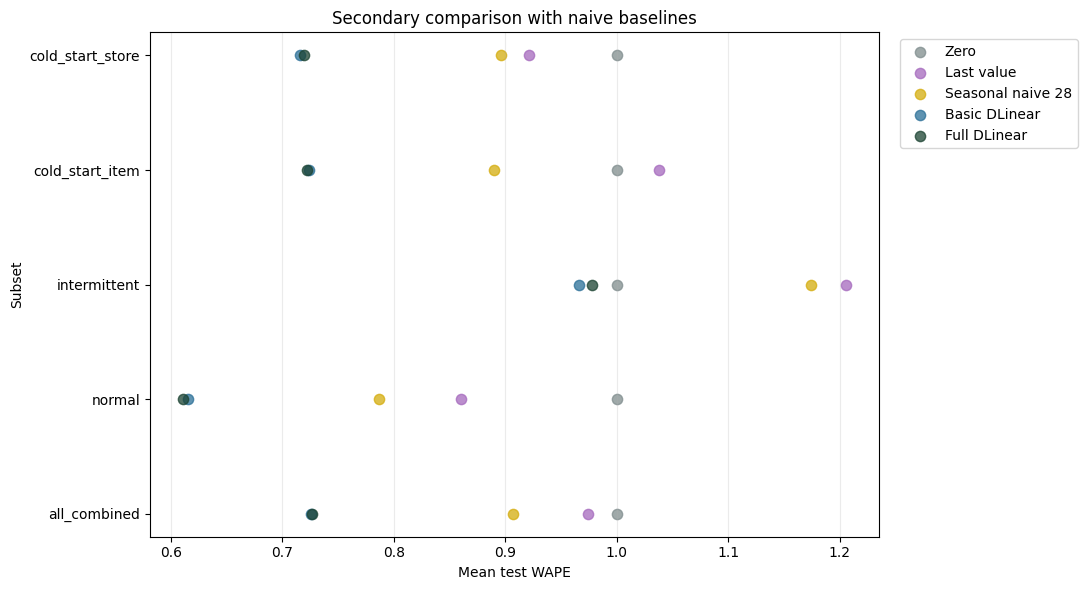

In [18]:
baseline_labels = {
    "zero": "Zero",
    "last_value": "Last value",
    "seasonal_naive_28": "Seasonal naive 28",
    "Basic DLinear": "Basic DLinear",
    "Full DLinear": "Full DLinear",
}
baseline_colors = {
    "zero": "#7F8C8D",
    "last_value": "#A569BD",
    "seasonal_naive_28": "#D4AC0D",
    "Basic DLinear": "#2A6F97",
    "Full DLinear": "#1B4332",
}
subset_positions = {
    subset: position for position, subset in enumerate(SUBSET_ORDER)
}

plt.figure(figsize=(11, 6))

for model_name in baseline_order:
    model_data = baseline_context[
        baseline_context["model_name"] == model_name
    ]
    y_values = model_data["subset"].map(subset_positions)

    plt.scatter(
        model_data["wape"],
        y_values,
        label=baseline_labels[model_name],
        color=baseline_colors[model_name],
        alpha=0.75,
        s=55,
    )

plt.yticks(range(len(SUBSET_ORDER)), SUBSET_ORDER)
plt.xlabel("Mean test WAPE")
plt.ylabel("Subset")
plt.title("Secondary comparison with naive baselines")
plt.grid(axis="x", alpha=0.25)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 11. Selected configurations

Each model selected one configuration using aggregate validation WAPE. Test subsets did not select separate configurations.

In [16]:
selected_files = {
    "Basic DLinear": "basic_dlinear_selected_config.json",
    "Past-Covariate DLinear": "past_covariates_selected_config.json",
    "Past-and-Future-Covariate DLinear": "future_covariates_selected_config.json",
    "Zero-Aware DLinear": "zero_aware_selected_config.json",
    "Metadata DLinear": "metadata_selected_config.json",
    "Full DLinear": "full_model_selected_config.json",
}

selected_rows = []

for model_name, file_name in selected_files.items():
    with open(GRID_DIR / file_name, encoding="utf-8") as file:
        selected_rows.append(json.load(file))

selected_configs = pd.DataFrame(selected_rows)
selected_configs[
    [
        "model_name",
        "selected_run_id",
        "seq_len",
        "learning_rate",
        "samples_per_epoch",
        "selected_epochs",
        "validation_wape",
        "validation_rmse",
    ]
]

,model_name,selected_run_id,seq_len,learning_rate,samples_per_epoch,selected_epochs,validation_wape,validation_rmse
0,Basic DLinear,basic_dlinear_search_16,112,0.0003,10000,31,0.729993,2.310613
1,Past-Covariate DLinear,past_covariates_search_08,56,0.0010,20000,46,0.722514,2.359573
2,Past-and-Future-Covariate DLinear,future_covariates_search_08,56,0.0010,20000,46,0.724152,2.358341
3,Zero-Aware DLinear,zero_aware_search_04,28,0.0003,10000,14,0.733750,2.313241
4,Metadata DLinear,metadata_search_08,56,0.0010,20000,46,0.722137,2.358832
5,Full DLinear,full_model_search_06,28,0.0003,40000,10,0.733934,2.298016


## Final interpretation

The following conclusions use the mean of five final seeds:

- **Basic DLinear has the best all-combined WAPE.** Full DLinear changes WAPE from 0.7262 to 0.7270, a deterioration of 0.11%, and beats Basic WAPE in only two of five seeds.
- **Past covariates, future-known covariates, and metadata are not supported as standalone improvements.** Their all-combined WAPE is approximately 1.04% to 1.18% worse than Basic DLinear, and none beats Basic consistently.
- **Full DLinear provides the strongest multi-metric alternative.** It improves all-combined RMSE by 1.84% and zero F1 by 2.63 percentage points, but does not improve overall WAPE.
- **The strongest Full-model point-forecast improvements occur for normal and cold-start-item series.** WAPE improves by 0.71% for normal series and 0.19% for cold-start items. Cold-start-item RMSE improves by 5.46%.
- **Basic DLinear remains best for intermittent and cold-start-store WAPE.** Full DLinear improves RMSE and zero F1 in these subsets but does not improve their WAPE.
- **The metric trade-off is caused by zero-day errors.** Full and Zero-Aware models reduce error on nonzero-demand days, but positive expected forecasts on actual zero days add WAPE. This effect is strongest for intermittent demand.
- **All models underpredict total demand.** Basic predicts 74.80% of all-combined actual demand, compared with 82.49% for Zero-Aware and 83.29% for Full DLinear. This helps explain their lower RMSE.

Therefore, **Basic DLinear is the preferred model when MAE/WAPE and simplicity are the priorities**. **Full DLinear is preferred when RMSE, zero-demand classification, and a balanced multi-metric result are more important**. The results do not justify the standalone Past-Covariate, Future-Covariate, or Metadata versions.

These findings are limited to five training seeds and one final 28-day test horizon. The test results should not be used for additional hyperparameter tuning.